# ✅ Auth + Setup

## 🔐 **Authenticate to Google Cloud within Colab**

Authenticate to Google Cloud as the IAM user logged into this notebook in order to access your Google Cloud Project.

In [ ]:
from google.colab import auth

auth.authenticate_user()

## 💻 **Install Code Dependencies**
It is recommended to use the Connector alongside a library that can create connection pools, such as [SQLAlchemy](https://www.sqlalchemy.org/).
This will allow for connections to remain open and be reused, reducing connection overhead and the number of connections needed

Let's `pip install` the [Cloud SQL Python Connector](https://github.com/GoogleCloudPlatform/cloud-sql-python-connector) as well as [SQLAlchemy](https://www.sqlalchemy.org/), using the below command.

In [ ]:
# install dependencies
import sys
!{sys.executable} -m pip install cloud-sql-python-connector["pymysql"] SQLAlchemy==2.0.7

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 52.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 85.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: SQLAlchemy
    Found existing installation: SQLAlchemy 2.0.16
    Uninstalling SQLAlchemy-2.0.16:
      Successfully uninstalled SQLAlchemy-2.0.16


In [ ]:
import google.auth
import pandas as pd

from google.cloud.sql.connector import Connector
from google.auth.transport.requests import Request
from sqlalchemy import create_engine, Table, Column, Integer, VARCHAR, ForeignKey, String, MetaData, text, select
from sqlalchemy.orm import Session

## 🐬 **Connect to a MySQL Instance**
We are now ready to connect to a MySQL instance using the Cloud SQL Python Connector! 🐍 ⭐ ☁


In [ ]:
# initialize parameters
INSTANCE_CONNECTION_NAME = "inlaid-woods-388716:us-west1:ilkmaar" # i.e demo-project:us-central1:demo-instance
print(f"Your instance connection name is: {INSTANCE_CONNECTION_NAME}")

# IAM database user parameter (IAM user's email before the "@" sign, mysql truncates usernames)
# ex. IAM user with email "demo-user@test.com" would have database username "demo-user"
# grant Cloud SQL Client role to authenticated user
current_user = !gcloud auth list --filter=status:ACTIVE --format="value(account)"

IAM_USER = current_user[0].split("@")[0]
DB_NAME = "gameplay-data"

Your instance connection name is: inlaid-woods-388716:us-west1:ilkmaar


### ✅ **Connect to Database**
To connect to Cloud SQL using the connector, initialize a `Connector` object and call its `connect` method with the proper input parameters.

In [ ]:
# initialize connector
connector = Connector()

# getconn now using IAM user and requiring no password with IAM Auth enabled
def getconn():
    conn = connector.connect(
      INSTANCE_CONNECTION_NAME,
      "pymysql",
      user=IAM_USER,
      db=DB_NAME,
      enable_iam_auth=True
    )
    return conn

# create connection pool
engine = create_engine(
    "mysql+pymysql://",
    creator=getconn,
)

def query_db(query_str):
    with engine.connect() as conn:
        return pd.read_sql_query(text(query_str), conn)

### Test Connection

This fails if the user does not have access to that database yet.

To fix:
  - log into the MySQL server on the Google Cloud Shell as root user
  - MySQL > GRANT ALL PRIVILEGES on `gameplay-data`.* to "user"@'%'

In [ ]:
# connect to connection pool
with engine.connect() as db_conn:
    # get current datetime from database
    results = db_conn.execute(text("SELECT NOW()")).fetchone()

    # output time
    print("Current time: ", results[0])

Current time:  2023-06-27 14:29:20


## ❓Queries Setup

In [ ]:
query_store = {}

def ask(question):
    for report in query_store.values():
        if report['question'] == question:
            result = query_db(report['query'])
            return result
    return "Sorry, I don't have a query for that question."

def show(report_name):
    if report_name in query_store:
        result = query_db(query_store[report_name]['query'])
        return result
    else:
        return "Sorry, I don't have a query for that report."

players = query_db("SELECT * from players")
creatures = query_db("SELECT * from creatures")
location_groups = query_db("SELECT * from location_groups")
recipes = query_db("SELECT recipe_name from recipes")

def visitor_log_query(location_group):
    q = f"""
        SELECT
            creature_sightings.creature_sighting_time,
            creatures.creature_name
        FROM
            creature_sightings
        JOIN
            creatures on creature_sightings.creature_id = creatures.creature_id
        JOIN
            location_groups on creature_sightings.location_group_id = location_groups.location_group_id
        WHERE
            location_group_name like '{location_group}'
        ORDER BY time DESC
        LIMIT 10
    """
    return q

def recipe_book_query(recipe_name):
    q = f"""SELECT recipe_name, resource_type, resource_type_faction
        FROM recipes
        JOIN recipe_ingredient_resource_types ON recipes.recipe_id = recipe_ingredient_resource_types.recipe_id
        JOIN resource_types ON recipe_ingredient_resource_types.resource_type_id = resource_types.resource_type_id
        WHERE recipes.recipe_name like '{recipe_name}'
    """
    return q

def cauldron_query():
    q = f"""
        SELECT
            DISTINCT recipes.recipe_name, recipes.recipe_temp, recipes.recipe_difficulty
        FROM
            recipes
        JOIN
            recipe_ingredient_resource_types on recipes.recipe_id = recipe_ingredient_resource_types.recipe_id
    """
    return q

def crafting_table_query(player_name):
    q = f"""
        SELECT
            crafting_event_time,
            recipe_name
        FROM
            crafting_events
        JOIN
            recipes on crafting_events.recipe_id = recipes.recipe_id
        JOIN
            collections on crafting_events.crafting_table_collection_id = collections.collection_id
        JOIN
            player_collection_access on collections.collection_id = player_collection_access.collection_id
        JOIN
            players on player_collection_access.player_id = players.player_id
        WHERE
            players.player_name like '{player_name}'
        ORDER BY time DESC
        LIMIT 10
    """
    return q

def trash_bin_query(player_name):
    q = f"""
        SELECT
            resource_transfer_time,
            resource_types.resource_type,
            resource_transfers.resource_id
        FROM
            resource_transfers
        JOIN
            collections on resource_transfers.destination_collection_id = collections.collection_id
        JOIN
            player_collection_access on collections.collection_id = player_collection_access.collection_id
        JOIN
            players on player_collection_access.player_id = players.player_id
        JOIN
            resources on resource_transfers.resource_id = resources.resource_id
        JOIN
            resource_types on resources.resource_type_id = resource_types.resource_type_id
        WHERE
            players.player_name like '{player_name}'
        AND
            collections.collection_type = 'crafting_table'
        ORDER BY resource_transfers.resource_transfer_time DESC
        LIMIT 30
    """
    return q

def creature_interactions_query(creature_name):
    q = f"""
        SELECT interaction_event_time, location_groups.location_group_name, locations.location_x, locations.location_y, players.player_name
        FROM
            interaction_events
        JOIN
            creatures on interaction_events.creature_id = creatures.creature_id
        JOIN
            players on interaction_events.player_id = players.player_id
        JOIN
            locations on interaction_events.location_id = locations.location_id
        JOIN
            location_groups on locations.location_group_id = location_groups.location_group_id
        WHERE
            creature_name like '{creature_name}'
    """
    return q

def player_foraging_query(player_name):
    q = f"""
          SELECT
              resource_transfers.resource_transfer_time,
              resource_transfers.resource_id,
              resource_types.resource_type as resource,
              source_collections.collection_name AS 'map area'
          FROM
              resource_transfers
          JOIN
              resources ON resource_transfers.resource_id = resources.resource_id
          JOIN
              resource_types ON resources.resource_type_id = resource_types.resource_type_id
          JOIN
              collections AS source_collections ON resource_transfers.source_collection_id = source_collections.collection_id
          JOIN
              collections AS destination_collections ON resource_transfers.destination_collection_id = destination_collections.collection_id
          JOIN
              player_collection_access ON destination_collections.collection_id = player_collection_access.collection_id
          JOIN
              players ON player_collection_access.player_id = players.player_id
          WHERE
              players.player_name like '{player_name}'
          AND
              destination_collections.collection_type = 'inventory'
          ORDER BY
              resource_transfers.resource_transfer_time DESC
      """
    return q

def player_gifting_query(player_name):
    q = f"""
        SELECT gifting_events.gifting_event_time, creatures.creature_name, recipes.recipe_name
        FROM
            gifting_events
        LEFT JOIN
            interaction_events on gifting_events.gifting_event_id = interaction_events.gifting_event_id
        JOIN
            creatures on interaction_events.creature_id = creatures.creature_id
        JOIN
            players on interaction_events.player_id = players.player_id
        JOIN
            item_transfers on gifting_events.item_transfer_id = item_transfers.item_transfer_id
        JOIN
            items on item_transfers.item_id = items.item_id
        JOIN
            recipes on items.recipe_id = recipes.recipe_id
        WHERE
            player_name like '{player_name}'
    """
    return q

def creature_gifts_query(creature_name):
    q = f"""
        SELECT gifting_events.gifting_event_time, players.player_name, recipes.recipe_category
        FROM
            gifting_events
        LEFT JOIN
            interaction_events on gifting_events.gifting_event_id = interaction_events.gifting_event_id
        JOIN
            creatures on interaction_events.creature_id = creatures.creature_id
        JOIN
            players on interaction_events.player_id = players.player_id
        JOIN
            item_transfers on gifting_events.item_transfer_id = item_transfers.item_transfer_id
        JOIN
            items on item_transfers.item_id = items.item_id
        JOIN
            recipes on items.recipe_id = recipes.recipe_id
        WHERE
            creature_name like '{creature_name}'
    """
    return q

for _ , player in players.iterrows():
    player_name = player['player_name']
    query_store[f"{player_name}'s Crafting Table Log"] = {
        'question': f"Which recipes has {player_name} crafted recently?",
        'query': crafting_table_query(player_name)
    }

for _ , player in players.iterrows():
    player_name = player['player_name']
    query_store[f"{player_name}'s Gifting Log"] = {
        'question': f"Which items has {player_name} gifted recently?",
        'columns': ['gifting_event_time', 'creature_name', 'recipe_name'],
        'query': player_gifting_query(player_name)
    }

for _ , player in players.iterrows():
    player_name = player['player_name']
    query_store[f"{player_name}'s Foraging Log"] = {
        'question': f"Which resources has {player_name} foraged recently?",
        'query': player_foraging_query(player_name)
    }

for _ , player in players.iterrows():
    player_name = player['player_name']
    query_store[f"{player_name}'s Trash Bin"] = {
        'question': f"Which items has {player_name} consumed recently?",
        'query': trash_bin_query(player_name)
    }

for _ , creature in creatures.iterrows():
    creature_name = creature['creature_name']
    query_store[f"{creature_name}'s Gift Memories"] = {
        'question': f"What gifts has {creature_name} gotten recently?",
        'query': creature_gifts_query(creature_name)
    }

for _ , creature in creatures.iterrows():
    creature_name = creature['creature_name']
    query_store[f"{creature_name}'s Location Memories"] = {
        'question': f"Who has {creature_name} interacted with recently?",
        'query': creature_interactions_query(creature_name)
    }

for _ , location_group in location_groups.iterrows():
    location_group_name = location_group['location_group_name']
    query_store[f"{location_group_name} Visitor Log"] = {
        'question': f"Who has been seen in {location_group_name} recently?",
        'query': visitor_log_query(location_group_name)
    }

for _ , recipe in recipes.iterrows():
    recipe_name = recipe['recipe_name']
    query_store[f"{recipe_name} Recipe"] = {
        'question': f"What ingredients do I need to cook {recipe_name}?",
        'query': recipe_book_query(recipe_name)
    }

query_store['Cauldron Instructions'] = {
    'question': f"What temperature do I cook recipes at?",
    'query': cauldron_query()
}

query_store['Triage Critical Condition List'] = {
    'question': f"Who are the sickest creatures?",
    'query': "SELECT creature_name, creature_faction, creature_health FROM creatures ORDER BY creature_health ASC LIMIT 10"
}

In [ ]:
!{sys.executable} -m pip install plotly

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import plotly.graph_objects as go
import plotly.express as px

def show_as_table(title):
    query = query_store[title]['query']
    df = query_db(query)
    fig = go.Figure(data=[go.Table(
        header=dict(values=list(df.columns),
                    fill_color='paleturquoise',
                    align='left'),
        cells=dict(values=[df[col] for col in df.columns],
                  fill_color='lavender',
                  align='left'))
    ])
    fig.show()

def show_as_bar_chart(title, categorical_column_for_x, numeric_column_for_y):
    query = query_store[title]['query']
    df = query_db(query)

    color_dict = {
        'Shadow': 'darkblue',
        'Light': 'yellow',
        'Growth': 'green',
        'Stability': 'grey'
    }

    # Create a bar chart
    fig = go.Figure(data=[
        go.Bar(
            name='Column 1',
            x=df[categorical_column_for_x], # categorical type
            y=df[numeric_column_for_y], # numeric type
            marker_color=[color_dict[i] for i in df[categorical_column_for_x]]
        )
    ])
    fig.update_layout(barmode='group')
    fig.show()

def show_as_plot(title, column_x, column_y):
    # Create a scatter plot
    query = query_store[title]['query']
    df = query_db(query)

    fig = px.scatter(df, x=column_x, y=column_y)

    fig.show()

def show_as_map(title, x, y, color_column):
    query = query_store[title]['query']
    df = query_db(query)

    # Create a scatter plot
    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=df[x],
            y=df[y],
            mode='markers',
            marker=dict(color=color_column)
        )
    )

    fig.update_layout(
        autosize=False,
        width=1000,
        height=1000,
        images=[dict(
            source="https://i.imgur.com/MH1kzqg.png",  # map image URL
            xref="x",
            yref="y",
            x=-100,
            y=100,
            sizex=200,
            sizey=200,
            sizing="stretch",
            opacity=0.5,
            layer="below")])

    # Set the range of x and y axis with padding
    fig.update_xaxes(range=[-100, 100])
    fig.update_yaxes(range=[-100, 100])

    fig.show()

# 🔍 Data Interactions

## SEEK


I'm in the potions clinic. I look at the creatures in line.

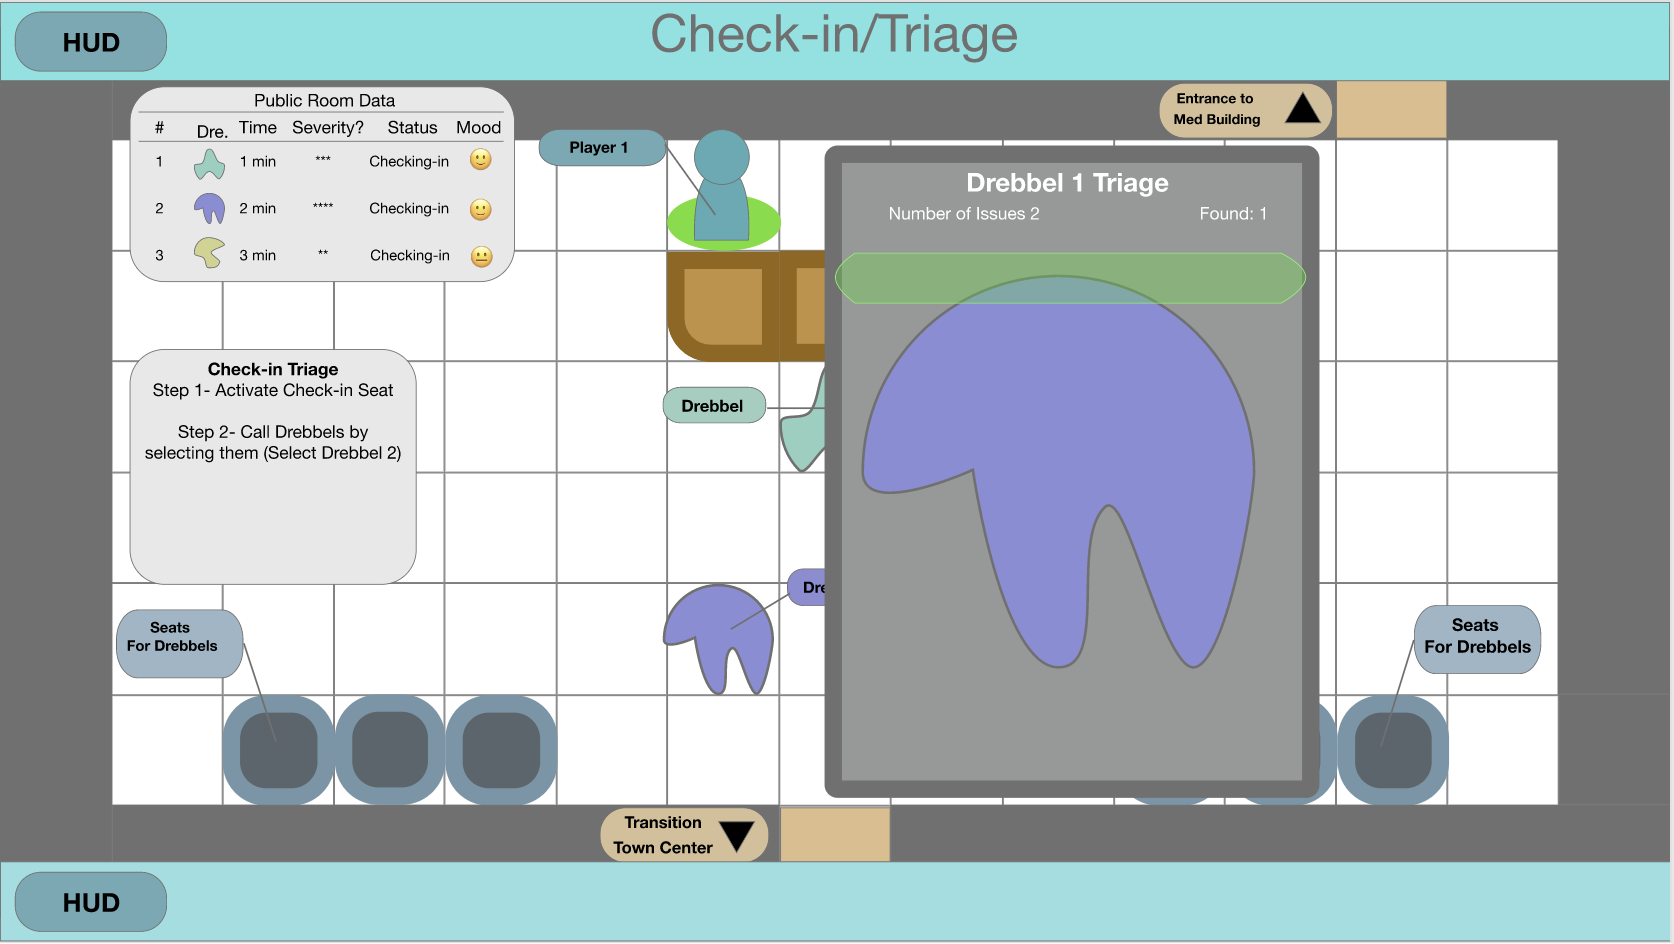

I look at the list that shows them by least healthy, so I know who to help most.


In [ ]:
show_as_table("Triage Critical Condition List")

#
# Amethyst is the most sick.
#

In [ ]:
#
# Amethyst is really sick. Why?
#

#
# I read in the Newspaper that some creatures might get sick if they
# go to a contaminated location, or eat items that make them sick.
# I'll ask Amethyst where she remembers visiting.
# Maybe there will be a pattern with other sick creatures.
#

show_as_table("Amethyst 's Location Memories") # ignore the extra space in the name i forgot to sanitize input data

#
# She went to the Growth Tree most... but also went to other places, idk
#

In [ ]:
#
# Sometimes they're sick because they ate something poisonous?
# I'll ask Aurora what gifts she has been given to eat.
#

show_as_table("Amethyst 's Gift Memories")

#
# I see that Emiko gave her a treat.
# And Hannah gave her a potion just yesterday.
#

In [ ]:
#
# Hannah and Emiko gave me access to their gifting data. Let me check...
#

#show("Emiko's Gifting Log")
show_as_table("Hannah's Gifting Log")

#
# Ah, I see that Emiko gave Amethyst a "Golden Honeydew Fusion"
# And Hannah gave her a "Growthfire Leaf Fusion"...
#

In [ ]:
# Q: Does 'Growthfire Leaf Fusion' make Light types sick?
# I could look at the potions clinic log and see if other sick Light creatures had that.

# I remember reading in the Newspaper...
# that some types of recipes could make creatures sick depending on their faction...

# Let's see what ingredients are in the recipes Amethyst ate...

show_as_table('Growthfire Leaf Fusion Recipe') # Tranquil Moss (Growth) and Sugarleaf (Growth)
# show('Golden Honeydew Fusion Recipe')  # Stormfruit (Shadow) and Honeydew (Growth)

In [ ]:
# I see both of those are Growth type ingredients.
# So Maybe Growth type ingredients make Light type sick...
# I'd check the 'Golden Honeydew Fusion' recipe, but I don't have access yet!

# Maybe the other creatures in triage right now will also have eaten these ingredients?
# I'll go back to the Triage (and/or figure out where to find Iris) and ask her what she has been given.

show_as_table("Iris's Gift Memories")

In [ ]:
#show("Dalia's Gifting Log")
show("Hannah's Gifting Log")

# I see Dalia gave Iris an "Umbral Stonewood Token"
# and Hannah gave her a "Serene Hardwood Essence"... what even is that
# Lemme look at those recipes too

#show("Serene Hardwood Essence Recipe") # Ingredients: Stonewood (Stability), Hardwood (Growth)
show("Umbral Stonewood Token Recipe") # Ingredients: Stonewood (Stability), Shadowglass (Shadow)

# Kinda weird that creatures eat Stone, Hardwood and Glass but go off
# oh wait maybe that's bad for them
# oh wait she doesn't eat any Light type foods!
# maybe the other healthy creatures are actually just eating foods that are good for them
# ...how could I find healthiest creatures?

,recipe_name,resource_type,resource_type_faction
0,Umbral Stonewood Token,Stonewood,Stability
1,Umbral Stonewood Token,Shadowglass,Shadow


In [ ]:
# idk what kind of world object would maintain a list of healthiest creatures
# maybe we need a "Gold Star for Health Record" on the wall in the Potions Clinic...
# (so let's make one:)

query_store["Gold Star for Health Record"] = {
    'question': "Who are the healthiest creatures of them all?",
    'query': "SELECT creature_name, creature_health FROM creatures ORDER BY creature_health DESC LIMIT 10"
}

show("Gold Star for Health Record") # would be nice to attach these different queries to specific world objects...

,creature_name,creature_health
0,Viridius,145
1,Chlorophyll,133
2,Vanguard,127
3,Radiance,126
4,Evergreen,125
5,Zephyr,122
6,Solstice,115
7,Stalwart,113
8,Sylvan,110
9,Aurelia,107


In [ ]:
# Viridius! Who is that? I don't remember who "Viridius" is or what faction. Sounds Green

# You know what might be useful?
# A way to look up creature factions by name

query_store["Creature Faction Lookup Book"] = {
    'question': "What are all the creatures' factions?",
    'query': "SELECT creature_name, creature_faction, creature_color FROM creatures"
}

show("Creature Faction Lookup Book")

# OK I'm not reading all that
# Let's... 'flip to the page' on V

book = show("Creature Faction Lookup Book")
book[book['creature_name'] == "Viridius"]

,creature_name,creature_faction,creature_color
65,Viridius,Growth,Green


In [ ]:
# OK! So Viridius is Growth type
# Let's see what he ate that made him so health

show("Viridius's Gift Memories") # (Emiko, Potion) (Giselle, Food) (Chiara, Potion)

#
# Can look at players' gifting logs again...
# show("Chiara's Gifting Log") # Tranquility Moss Tonic (P), Twilight Stormfruit Surprise (F), Stalwart Stew (P)

# Then at ingredients again...

# ...boy this sure would be easier if I just looked at the crafting Logs,
# which in an updated version should definitely tell me the resources used to craft an item
# But anyway...

#show("Twilight Stormfruit Surprise Recipe") #Food: (Shadow, Growth)
#show("Tranquility Moss Tonic Recipe") #Potion: (Light, Growth)
show("Stalwart Stew Recipe") #Potion: (Light, Growth)

# OK so this one always eats foods with one of their own type of ingredient in them...!

,recipe_name,resource_type,resource_type_faction
0,Stalwart Stew,Moonberry,Light
1,Stalwart Stew,Sugarleaf,Growth


In [ ]:
# Actually I wonder if the ones in the middle range of health
# just keep eating both good and bad foods that balance out
# and maybe they eat more foods overall, they just balance
# like a food random walk

# This could/should just be medical records in the potions clinic but maybe u need access
# But maybe someone/somewhere in the game can have like all current records on something.
# e.g. a "Health Oracle"...

query_store["The Health Oracle"] = {
    'question': "What are all creatures' health levels?",
    'query': "SELECT creature_name, creature_faction, creature_health from creatures"
}

#show("The Health Oracle")

# Hmm we should have one for Mood, too
query_store["The Mood Oracle"] = {
    'question': "What are all creatures' mood levels?",
    'query': "SELECT creature_name, creature_faction, creature_mood from creatures ORDER BY creature_mood DESC"
}

show("The Mood Oracle")

# And why not a Top 10 like in the "Gold Star for Health Poster"
# Maybe something like this is a daily Newspaper 'article'...?
# "10 Healthiest Creatures: What do they eat!?"
# Could alternate with "10 Saddest Creatures: what makes them tick?"

query_store["Top 10 Happiest Creatures"] = {
    'question': "What are all creatures' mood levels?",
    'query': "SELECT creature_name, creature_faction, creature_mood from creatures ORDER BY creature_mood DESC LIMIT 10"
}

show("Top 10 Happiest Creatures")

# HA! The happiest creature is named "Gloomsong"...

,creature_name,creature_faction,creature_mood
0,Gloomsong,Shadow,140
1,Radiance,Light,137
2,Flora,Growth,119
3,Petal,Growth,107
4,Lastingheart,Stability,107
5,Umbertide,Shadow,104
6,Vanguard,Stability,103
7,Sunleaf,Growth,103
8,Violet,Light,100
9,Nightshade,Shadow,99


In [ ]:
# OK let's see what makes creatures so happy...
# (this actually seems like a very good type of "onboarding" clue)

show("Gloomsong's Gift Memories") # see: (0, Jasmine, Gift); (6, Dalia, Treat)
# show("Radiance's Gift Memories") # see 4, one of each type

# Ah, so Gloomsong got a Gift and a Treat and is happiest of all...
# Gifts and Treats definitely would have a mood effect...
# But wait, Radiance got a Treat, Food, Potion AND a Gift and is *less* happy...!

# So maybe the KIND of gifts/treats matters

,gifting_event_time,player_name,recipe_category
0,0,Jasmine,Gift
1,6,Dalia,Treat


## SQUISH

In [ ]:
# What did Jasmine and Dalia gift that Gloomsong liked so much?

# show("Jasmine's Gifting Log") # see: gave Gloomsong "Tranquilwood Harmony"
show("Dalia's Gifting Log") # see: gave Gloomsong "Golden Honeydew Fusion"

show("Tranquilwood Harmony Recipe") # (Nightshade, Shadow), (Shadowglass, Shadow)
# show("Golden Honeydew Fusion Recipe") # (Stormfruit, Shadow), (Honeydew, Growth)

# OK so this is REALLY tedious to keep looking up Gifts and THEN their recipes!
# What if there was some kind of way... to combine two information sources...

# So first let's make a more useful cookbook, which has faction type information too.
# (Maybe we unlock this by levelling up in Cooking or something.)

# Let's make a Super Useful Cook Book.
query_store["Super Useful Cook Book"] = {
    'question': "What ingredients do I need for different recipes?",
    'query': """
        SELECT recipes.recipe_id, recipes.recipe_name, resource_types.resource_type, resource_types.resource_type_faction
        FROM recipe_ingredient_resource_types
        JOIN recipes on recipe_ingredient_resource_types.recipe_id = recipes.recipe_id
        JOIN resource_types on recipe_ingredient_resource_types.resource_type_id = resource_types.resource_type_id
    """
}

# Actually let's make an Extremely Useful Cook Book. This one has 'rarity' information, too.
query_store["Extremely Useful Cook Book"] = {
    'question': "What ingredients do I need for different recipes, and how rare are they?",
    'query': """
        SELECT recipes.recipe_id, recipes.recipe_name, resource_types.resource_type, resource_types.resource_type_faction, resource_types.resource_type_rarity
        FROM recipe_ingredient_resource_types
        JOIN recipes on recipe_ingredient_resource_types.recipe_id = recipes.recipe_id
        JOIN resource_types on recipe_ingredient_resource_types.resource_type_id = resource_types_resource.type_id
    """
}

# No wait we could even make an God Mode Cook Book
query_store["God Mode Cook Book"] = {
    'question': "How can I know everything about recipes?",
    'query': """
        SELECT *
        FROM recipe_ingredient_resource_types
        JOIN recipes on recipe_ingredient_resource_types.recipe_id = recipes.recipe_id
        JOIN resource_types on recipe_ingredient_resource_types.resource_type_id = resource_types.resource_type_id
    """
}

# OK perfect-- so say we have one source of data: A Cook Book.
# Now let's say we have another: "Gloomsong's Gift Memories", the one we were just looking at.

# What if we could... squish them together...
# so that the Gifting Log also had all the information from the Cook Book?

def squish(title1, title2):
    query1 = query_store[title1]['query']
    query2 = query_store[title2]['query']

    new_query = f"""
        SELECT *
        FROM ({query1}) as table1
        JOIN ({query2}) as table2
        ON table1.recipe_name = table2.recipe_name;
    """
    return query_db(new_query)

# Now instead of going around looking up recipes whenever we want to figure out what a creature ate,
# we can just "squish" our Cook Book onto it!
squish("Jasmine's Gifting Log", "Super Useful Cook Book")

,gifting_event_time,creature_name,recipe_name,recipe_id,recipe_name,resource_type,resource_type_faction
0,8,Shadowthorn,Shadowy Mushroomburst,21,Shadowy Mushroomburst,Ghostcap Mushroom,Shadow
1,8,Shadowthorn,Shadowy Mushroomburst,21,Shadowy Mushroomburst,Ironroot,Stability
2,3,Seraphim,Luminescent Sugarleaf Bliss,42,Luminescent Sugarleaf Bliss,Sugary Stardust,Light
3,3,Seraphim,Luminescent Sugarleaf Bliss,42,Luminescent Sugarleaf Bliss,Sugarleaf,Growth
4,3,Resolute,Umbral Shadowberry Surprise,55,Umbral Shadowberry Surprise,Shadowberry,Shadow
5,3,Resolute,Umbral Shadowberry Surprise,55,Umbral Shadowberry Surprise,Stormfruit,Shadow
6,3,Nightshade,Umbral Shadowberry Surprise,55,Umbral Shadowberry Surprise,Shadowberry,Shadow
7,3,Nightshade,Umbral Shadowberry Surprise,55,Umbral Shadowberry Surprise,Stormfruit,Shadow
8,5,Prismaros,Stardust Twilight Delight,67,Stardust Twilight Delight,Sugary Stardust,Light
9,5,Prismaros,Stardust Twilight Delight,67,Stardust Twilight Delight,Nightshade,Shadow


In [ ]:
# But yuck, that's a lot of columns. And a bunch are redundant.
# This can be improved if in my query_store I store column names, standardize them,
# and build the query in a smarter way...

query_store["Super Useful Cook Book"]['columns'] = ['recipe_id', 'recipe_name', 'resource_type', 'resource_type_faction']
query_store["Extremely Useful Cook Book"]['columns'] = ['recipe_id', 'recipe_name', 'resource_type', 'resource_type_faction']
# Note this wouldn't work yet with my God Mode cookbook because of the SELECT *
query_store["Jasmine's Gifting Log"]['columns'] = ['gifting_event_time', 'creature_name', 'recipe_name']
query_store["Creature Faction Lookup Book"]['columns'] = ['creature_name', 'creature_faction', 'creature_color']
query_store["The Mood Oracle"]['columns'] = ['creature_faction', 'creature_name', 'creature_mood']

def squish(title1, title2):
    query1 = query_store[title1]['query']
    query2 = query_store[title2]['query']

    columns1 = set(query_store[title1]['columns'])
    columns2 = set(query_store[title2]['columns'])

    joinable_columns = list(columns1.intersection(columns2))
    columns_to_select = ", ".join(list(columns1.union(columns2)))

    if len(joinable_columns) == 1:
        join_column = joinable_columns[0]

        # Remove join_column from the sets and form the rest of the select statement
        columns1.discard(join_column)
        columns2.discard(join_column)
        columns_to_select = ", ".join(["table1." + col for col in columns1] + ["table2." + col for col in columns2])

        new_query = f"""
            SELECT table1.{join_column}, {columns_to_select}
            FROM ({query1}) as table1
            JOIN ({query2}) as table2
            ON table1.{join_column} = table2.{join_column}
        """
        return query_db(new_query)
    elif len(joinable_columns) > 1:
        return "Ambiguous. Need more info."
    else:
        return f"No can do squish. Columns1: {columns1}, Columns2: {columns2}"

# Excellent!
squish("Jasmine's Gifting Log", "Super Useful Cook Book")

,recipe_name,creature_name,gifting_event_time,recipe_id,resource_type_faction,resource_type
0,Shadowy Mushroomburst,Shadowthorn,8,21,Shadow,Ghostcap Mushroom
1,Shadowy Mushroomburst,Shadowthorn,8,21,Stability,Ironroot
2,Luminescent Sugarleaf Bliss,Seraphim,3,42,Light,Sugary Stardust
3,Luminescent Sugarleaf Bliss,Seraphim,3,42,Growth,Sugarleaf
4,Umbral Shadowberry Surprise,Resolute,3,55,Shadow,Shadowberry
5,Umbral Shadowberry Surprise,Resolute,3,55,Shadow,Stormfruit
6,Umbral Shadowberry Surprise,Nightshade,3,55,Shadow,Shadowberry
7,Umbral Shadowberry Surprise,Nightshade,3,55,Shadow,Stormfruit
8,Stardust Twilight Delight,Prismaros,5,67,Light,Sugary Stardust
9,Stardust Twilight Delight,Prismaros,5,67,Shadow,Nightshade


In [ ]:
# Now if I was in the medical building (or anywhere) and I wanted to know what ingredients were used...
# I could just "squish" my Cook Book onto it.

# Note: squishing the opposite direction should work too-- squishing the Gifting Log onto the Cook Book.
# The distinction matters when one has partial information-- e.g. I don't have access to all recipes yet.

# Also note: this basically gives me a list of all ingredients the player has ever used in their gifts.
# If the creatures had actually remembered gift item (instead of just gift type) this would be another way
# to create a list of all ingredients the creature had consumed.

# Which in this specific fake investigation would be pretty useful!
# So instead what we could do...

# What if we looked at all gifting data at once (that we had access to, say)?
# Or, if all/most crafting is done on a "community crafting table"-- I could look at those records and squish my cook book onto it too.

query_store["All-Player Shared Gifting Log"] = {
    'question': "What has everyone gifted?",
    'columns': ['gifting_event_time', 'recipe_name', 'creature_name'], # should match individual gift logs...
    'query': """
        SELECT gifting_events.gifting_event_time, recipes.recipe_name, creatures.creature_name
        FROM gifting_events
        JOIN item_transfers on gifting_events.item_transfer_id = item_transfers.item_transfer_id
        JOIN items on item_transfers.item_id = items.item_id
        JOIN recipes on items.recipe_id = recipes.recipe_id
        JOIN creatures on gifting_events.creature_id = creatures.creature_id
    """
}

# OK now we have a log of all gifts:
show("All-Player Shared Gifting Log")

,gifting_event_time,recipe_name,creature_name
0,0,Crystal Water Infusion,Zephyrus
1,0,Radiant Fig Fusion,Mosswhisper
2,0,Twilight Shadow Crystal,Petal
3,0,Serene Hardwood Essence,Endurance
4,0,Golden Honeydew Fusion,Amethyst
...,...,...,...
154,9,Serene Hardwood Essence,Mossbane
155,9,Radiant Sunfruit Surprise,Chlorophyll
156,9,Lunar Glowberry Elixir,Ember
157,9,Umbral Stonewood Token,Zephyrus


In [ ]:
# But we only want to look at Gloomsong. Or Amethyst.
book = show("All-Player Shared Gifting Log")
book[book['creature_name'] == 'Gloomsong']

# Now we have everything they've been gifted.

,gifting_event_time,recipe_name,creature_name
11,0,Tranquilwood Harmony,Gloomsong
109,6,Golden Honeydew Fusion,Gloomsong


In [ ]:
# Let's squish it with our Cook Book
book = squish("All-Player Shared Gifting Log", "Super Useful Cook Book")

book[book['creature_name'] == 'Gloomsong'] # And filter down to only for the creature we're interested in...

# Now we have all ingredients Gloomsong has eaten!
# (I'm getting convinced here that tables + filtering + squishing will go a long way)

,recipe_name,creature_name,gifting_event_time,recipe_id,resource_type_faction,resource_type
98,Golden Honeydew Fusion,Gloomsong,6,58,Shadow,Stormfruit
99,Golden Honeydew Fusion,Gloomsong,6,58,Growth,Honeydew
284,Tranquilwood Harmony,Gloomsong,0,133,Shadow,Nightshade
285,Tranquilwood Harmony,Gloomsong,0,133,Shadow,Shadowglass


In [ ]:
# Ah but wait, wouldn't it be nice to be able to squish this *again* with my Creature Phone Book?
# Then I could do things like see creature Faction compared to what they ate.
# Which would normally be complicated but in this game could just be "squishing" 2 items together
# (Which could also re-use the inventory and crafting UI for combining 2 objects into a new one)

# So if I 'squished' Gifting Log + Cook Book with the Health Oracle (or any recent medical records) I could see...
# creature health AND everything they ate.
# That seems pretty useful!

# But we'd need a new and improved squish... that could be *chained*

# So I'll have 'squish' return the title of a new object that can be looked up in query_store
# and then I'll have to look up and run the final result query

def squish(title1, title2):
    q1 = query_store[title1]
    q2 = query_store[title2]

    query1 = q1['query']
    query2 = q2['query']

    # This is the cringiest code ever dont look
    columns1 = set(q1['columns'])
    columns2 = set(q2['columns'])
    columns1_only = columns1 - columns2
    columns2_only = columns2 - columns1
    shared_columns = list(columns1.intersection(columns2))
    unshared_columns = list(columns1.union(columns2))

    if len(shared_columns) >= 1:
        new_title = f"{title1}_squish_{title2}"

        # need to replace t1 and t2 now since they'll make the 'selects' ambiguous. ugh
        table1 = "`" + title1 + "`"
        table2 = "`" + title2 + "`"

        columns_to_select = ", ".join([f"{table1}." + col for col in columns1] + [f"{table2}." + col for col in columns2_only])
        join_condition = " AND ".join([f"{table1}.{col} = {table2}.{col}" for col in shared_columns])

        new_query = f"""
            SELECT {columns_to_select}
            FROM ({query1}) as {table1}
            JOIN ({query2}) as {table2}
            ON {join_condition}
        """

        query_store[new_title] = {
            'question': f"What do you get when you squish {title1} and {title2}?",
            'columns': shared_columns + list(columns1_only) + list(columns2_only),
            'query': new_query
        }
        return new_title
    else:
        return f"No can do squish. Columns1: {columns1}, Columns2: {columns2}"

# Let's see if this works.
# This represents squishing the Gifting Log and Cook Book...
# and THEN squishing the Creature Faction Lookup Book
#squish("All-Player Shared Gifting Log", "Super Useful Cook Book")


# YASSSSSSSS
title = squish(squish("All-Player Shared Gifting Log", "Super Useful Cook Book"), "Creature Faction Lookup Book")
query_db(query_store[title]['query'])

# It's... beautiful...
# tho would benefit from column ordering settings and naming etc, order gets lost in the 'set' I think

,gifting_event_time,recipe_name,creature_name,recipe_id,resource_type,resource_type_faction,creature_faction,creature_color
0,8,Rusted Stardusties,Ambrose,1,Sugary Stardust,Light,Stability,Red
1,8,Rusted Stardusties,Ambrose,1,Ironroot,Stability,Stability,Red
2,8,Luminous Sunburst,Gleam,2,Glowbug,Light,Growth,Yellow
3,8,Luminous Sunburst,Gleam,2,Sunfruit,Light,Growth,Yellow
4,6,Luminous Sunburst,Vanguard,2,Glowbug,Light,Stability,Blue
...,...,...,...,...,...,...,...,...
311,4,Serene Hardwood Essence,Grit,139,Hardwood,Growth,Stability,Purple
312,0,Serene Hardwood Essence,Endurance,139,Stonewood,Stability,Stability,Green
313,0,Serene Hardwood Essence,Endurance,139,Hardwood,Growth,Stability,Green
314,1,ShaToken,Mossbane,140,Shadowglass,Shadow,Shadow,Green


In [ ]:
# Let's keep going and squish on the Health Oracle too!

# Gotta give it some columns first
query_store["The Health Oracle"]['columns'] = ['creature_name', 'creature_faction', 'creature_health']

title = squish(squish(squish("All-Player Shared Gifting Log", "Super Useful Cook Book"), "Creature Faction Lookup Book"), "The Health Oracle")
query_db(query_store[title]['query'])

# OMG IT WORKS

,gifting_event_time,creature_color,recipe_name,creature_name,recipe_id,resource_type,resource_type_faction,creature_faction,creature_health
0,8,Red,Rusted Stardusties,Ambrose,1,Sugary Stardust,Light,Stability,63
1,8,Red,Rusted Stardusties,Ambrose,1,Ironroot,Stability,Stability,63
2,8,Yellow,Luminous Sunburst,Gleam,2,Glowbug,Light,Growth,61
3,8,Yellow,Luminous Sunburst,Gleam,2,Sunfruit,Light,Growth,61
4,6,Blue,Luminous Sunburst,Vanguard,2,Glowbug,Light,Stability,127
...,...,...,...,...,...,...,...,...,...
315,4,Purple,Serene Hardwood Essence,Grit,139,Hardwood,Growth,Stability,56
316,0,Green,Serene Hardwood Essence,Endurance,139,Stonewood,Stability,Stability,78
317,0,Green,Serene Hardwood Essence,Endurance,139,Hardwood,Growth,Stability,78
318,1,Green,ShaToken,Mossbane,140,Shadowglass,Shadow,Shadow,68


## SORT

In [ ]:
from sqlalchemy.sql.ddl import sort_tables_and_constraints

# Now we can see all ingredients that Gloomsong ate (and all the factions those belong to)
book = query_db(query_store[title]['query'])
book[book['creature_name'] == 'Gloomsong']

#book[book['creature_faction'] == 'Shadow']

# OK. We have all the data we would need to figure out if creature_health depends on types of item consumed.
# BUT. I can't really do anything good with this
# Normally I'd just have a SQL query that grouped or ordered things, but this was created through 'squishes'
# I need a way to sort and group and stuff

# OK... what IF
# what if I can do what I did for 'squish' but again for a 'sort':

def sort(title, column):
    q = query_store[title]['query']
    columns = query_store[title]['columns']

    new_title = title + "_sortdesc_" + column

    new_query = f"""
        SELECT *
        FROM ({q}) as table_alias
        ORDER BY table_alias.{column} DESC
    """
    query_store[new_title] = {
        'question': f"What do you get when you sort {title} by '{column}'?",
        'columns': columns,
        'query': new_query
    }
    return new_title

# NICE.
# What this means is that we can manipulate tables like they're inventory objects.
# And use "tools" in our inventory to manipulate tables too.
# A "sorter tool" could be used on a table (just select which column) and the query that the object represents gets updated.
# So a DataInventoryObject has an associated query and a set of Squish events and Sorter/Group applications.
# They can be stored in a chain, and reversed with an "undo"

q = sort(sort(squish(squish(squish("All-Player Shared Gifting Log", "Super Useful Cook Book"), "Creature Faction Lookup Book"), "The Health Oracle")
, 'creature_faction'), 'resource_type_faction')
query_db(query_store[q]['query'])

,gifting_event_time,creature_color,recipe_name,creature_name,recipe_id,resource_type,resource_type_faction,creature_faction,creature_health
0,1,Blue,Growthfire Crystal Delight,Nyx,116,Crystal Water,Stability,Shadow,81
1,8,Red,Rusted Stardusties,Ambrose,1,Ironroot,Stability,Stability,63
2,0,Green,Serene Hardwood Essence,Endurance,139,Stonewood,Stability,Stability,78
3,4,Purple,Serene Hardwood Essence,Grit,139,Stonewood,Stability,Stability,56
4,5,Green,Serene Hardwood Essence,Verdigris,139,Stonewood,Stability,Shadow,86
...,...,...,...,...,...,...,...,...,...
315,4,Purple,Serene Hardwood Essence,Grit,139,Hardwood,Growth,Stability,56
316,2,Purple,Tranquil Stardust Elixir,Solidarity,75,Tranquil Moss,Growth,Stability,75
317,0,Green,Serene Hardwood Essence,Endurance,139,Hardwood,Growth,Stability,78
318,2,Green,Luminous Moon Moss Elixir,Zephyr,70,Tranquil Moss,Growth,Light,122


## AVERAGE

In [ ]:
# Let's make one more tool:
# a 'group-averager'
# advanced tool. much upgrade

def group_averager(title, columns_to_group, column_to_average):
    q = query_store[title]['query']
    columns = query_store[title]['columns']

    new_title = title + "_group_" + columns_to_group[0] + "_avg_" + column_to_average
    columns_to_group_by = ", ".join(columns_to_group)
    all_columns = columns_to_group.append(column_to_average)

    new_query = f"""
        SELECT {columns_to_group_by}, AVG({column_to_average})
        FROM ({q}) as table_alias
        GROUP BY {columns_to_group_by}
        ORDER BY AVG({column_to_average}) DESC
    """
    query_store[new_title] = {
        'question': f"What do you get when you average {column_to_average} by '{columns_to_group}'?",
        'columns': all_columns,
        'query': new_query
    }
    return new_title

#### OMGGGGG YAYYYYYY

q = sort(sort(squish(squish(squish("All-Player Shared Gifting Log", "Super Useful Cook Book"), "Creature Faction Lookup Book"), "The Health Oracle")
, 'creature_faction'), 'resource_type_faction')
n = group_averager(q, ['creature_faction'], 'creature_health')
query_db(query_store[n]['query'])

### So we can get to "average faction health" by combining: a phone book, a health oracle, and an "averager" tool
### Or we could get to "creature health vs ingredients consumed" from: crafting data, a cook book, a phone book, a health oracle, and an "averager" tool
### Is it insane? Yes
### Can we do data science by 'crafting' with really basic inventory objects? Yes

,creature_faction,AVG(creature_health)
0,Growth,84.6154
1,Light,82.6386
2,Stability,78.3205
3,Shadow,78.0123


In [ ]:
# OK so A: it looks like mood for Shadow type most affected by gifts/treats with Shadow ingredients!
# That would make sense...
# Just like Growth health was most affected by Growth ingredients in the Foods and Potions

# What kind of weird query would convince us of this?
# We could
#   1) look at all Potions made with Shadow ingredients and see if Shadow creatures who got those are healthier
#   2) look at all Potions with TWO Shadow ingredients and see if Shadow creatures who got those are healthier
#   3) maybe the opposite is true, and Potions made with Light ingredients make creatures most unhappy?

# OK let's go back to
q = group_averager(squish(squish(squish("All-Player Shared Gifting Log", "Super Useful Cook Book"), "Creature Faction Lookup Book"), "The Health Oracle"), ['creature_faction', 'resource_type_faction'], 'creature_health')
r = query_db(query_store[q]['query'])
r[r['creature_faction'] == "Light"]

,creature_faction,resource_type_faction,AVG(creature_health)
1,Light,Light,93.7727
2,Light,Shadow,86.8182
10,Light,Stability,77.5625
14,Light,Growth,71.5217


## COUNT

In [ ]:
def count_by_groups(title, columns_to_group):
    q = query_store[title]['query']
    columns = query_store[title]['columns']

    new_title = title + "_countby_" + "_".join(columns_to_group)
    columns_to_group_by = ", ".join(columns_to_group)

    new_query = f"""
        SELECT {columns_to_group_by}, COUNT(*) as count
        FROM ({q}) as table_alias
        GROUP BY {columns_to_group_by}
        ORDER BY COUNT(*) DESC
    """
    query_store[new_title] = {
        'question': f"How many are there in with the same '{columns_to_group}'?",
        'columns': columns_to_group_by,
        'query': new_query
    }
    return new_title

t = count_by_groups("Hannah's Gifting Log", ['creature_name'])
show_as_table(t)

In [ ]:
# Let's see if I can figure out where those ingredients were from.
# Maybe they were contaminated.

# Hmmm did Hannah craft this or trade for it in the shop?


# show("Hannah's Crafting Table Log")

# Hmm I see she made it on Day 8. But otherwise nothing really new here.

#show("Hannah's Trash Bin")

# find on day 8: Tranquil Moss#2333
# find on day 8: Sugarleaf#2331

# How could I track down where those came from...?
# If she traded for them with another player I could look at the Shop Exchange log...

# But maybe she foraged them herself... and I don't have access to her foraging data...
# Ah, I can bet where they came from.

# Where have *I* found Sugarleaf and Tranquilmoss?
show("Hannah's Foraging Log")

# Hmm that doesn't seem helpful! Too much info.
# I'll just select the resources I'm interested in...
r = show("Hannah's Foraging Log")
r[r['resource_id'] == 2331]

# Stability Mines and Growth Tree...

,resource_transfer_time,resource_id,resource,map area
9,8,2331,Sugarleaf,Growth Tree


In [ ]:
# WHERE HAS TRANQUIL MOSS BEEN

# World Data:
#
#   - Visitor Logs for each map area ("location group")
#   - Crafting Table Log for each player
#
# To get player or map area names:
#  query_db("SELECT * from players")['player_name'].tolist()
#  query_db("SELECT * from location_groups")['location_group_name'].tolist()
#  query_db("SELECT * from recipes")['recipe_name'].tolist()

# Look at a Visitor Log:
# show("Light Garden Visitor Log")

# Look at Cauldron instructions:
# show('Cauldron Instructions')

# Resource Finder
resource_type = "Tranquil Moss"  # Replace with the desired resource type

query_db(
    f""" SELECT
    resource_types.resource_type as resource,
    source_collections.collection_name AS source,
    COUNT(*) as count
FROM
    resource_transfers
JOIN
    resources ON resource_transfers.resource_id = resources.resource_id
JOIN
    resource_types ON resources.resource_type_id = resource_types.resource_type_id
JOIN
    collections AS source_collections ON resource_transfers.source_collection_id = source_collections.collection_id
JOIN
    collections AS destination_collections ON resource_transfers.destination_collection_id = destination_collections.collection_id
JOIN
    player_collection_access ON destination_collections.collection_id = player_collection_access.collection_id
JOIN
    players ON player_collection_access.player_id = players.player_id
WHERE
    destination_collections.collection_type = 'inventory'
AND
    resource_types.resource_type = '{resource_type}'
GROUP BY resource_types.resource_type, source_collections.collection_name
ORDER BY count DESC
"""
)

,resource,source,count
0,Tranquil Moss,Shadow Patch,8
1,Tranquil Moss,Growth Tree,8
2,Tranquil Moss,Shadow Mines,7
3,Tranquil Moss,Rock Garden,7
4,Tranquil Moss,Growth Patch,7
5,Tranquil Moss,Stability Mines,6
6,Tranquil Moss,Light Garden,4
7,Tranquil Moss,Light Tree,2


# Data Representations

## Tables

Tables are the most basic, default representation. Any data can be shown in a table.

In [ ]:
show_as_table("Aurora's Location Memories")

## Bar charts

Creating a bar chart involves choosing two columns: one to group by, and one to plot (must be numeric).

In [ ]:
# Creature health vs faction

show_as_bar_chart("The Health Oracle", 'creature_faction', 'creature_health')

In [ ]:
# Creature mood vs faction

s = squish("The Mood Oracle", "Creature Faction Lookup Book")

show_as_bar_chart(s, 'creature_faction', 'creature_mood')

In [ ]:
# Average health per faction

t = group_averager("The Health Oracle", ['creature_faction'], 'creature_health')
show_as_bar_chart(t, 'creature_faction', 'AVG(creature_health)')

## Plots

Plots involve selecting columns for the x and y axes. These can be categorical, numeric, or a combination.

### Categorical x Categorical

For example, this plot shows which players (categorical) have interacted with creatures in each map area (categorical).

The Count of each combination (player and area) could set the size or color of the dots.

In [ ]:
show_as_plot("Aurora's Location Memories", 'location_group_name', 'player_name')

NameError: ignored

### Numeric x Categorical

The following charts show numeric data (creature health or mood) against categorical data (creature faction).

In [ ]:
show_as_plot("The Health Oracle", 'creature_faction', 'creature_health')

In [ ]:
show_as_plot("The Mood Oracle", 'creature_faction', 'creature_mood')

### Categorical x Numeric

In [ ]:
# Gifts to each creature by day

show_as_plot("Hannah's Gifting Log", 'gifting_event_time', 'creature_name')

In [ ]:
# Gifts to each faction by day

s = squish("Hannah's Gifting Log", "Creature Faction Lookup Book")
show_as_plot(s, 'gifting_event_time', 'creature_faction')

### Numeric x Numeric

These would cover e.g. timeseries plots.

In [ ]:
# Here is Hannah's count of gifts given, by day:

t = count_by_groups("Hannah's Gifting Log", ['gifting_event_time'])
show_as_plot(t, 'gifting_event_time', 'count')

## Maps

Maps can be created from tables that have location data.

In [ ]:
# show_as_map(title="Luminara's Location Memories", x='location_x', y='location_y', color_column=None)
show_as_map(title="Luminara's Location Memories", x='location_x', y='location_y', color_column=None)